In [10]:
pip install pandas mlxtend openpyxl

In [11]:
pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


In [41]:
import pandas as pd
df = pd.read_csv('E:\\datamining\\MergedDataset.csv', low_memory=False)


In [45]:
# بررسی فراوانی مقادیر هر ستون
for column in df.columns:
    print(f'Frequency distribution for {column}:')
    print(df[column].value_counts())


Frequency distribution for Unnamed: 0:
Unnamed: 0
1656     81
2024     81
1973     81
3871     70
3292     70
         ..
3055      1
3056      1
3057      1
3060      1
10836     1
Name: count, Length: 3579, dtype: int64
Frequency distribution for App:
App
Bubble Shooter                    282
Solitaire                         243
Word Search                       192
Flashlight                        140
Block Puzzle                      128
                                 ... 
Add-On: Alcatel (h)                 1
Talking Ginger                      1
Motorbike Driving Simulator 3D      1
Mobile Number Tracker               1
Sya9a Maroc - FR                    1
Name: count, Length: 2974, dtype: int64
Frequency distribution for Category_x:
Category_x
GAME                   1387
FAMILY                 1006
TOOLS                   716
PHOTOGRAPHY             304
PERSONALIZATION         255
MEDICAL                 206
PRODUCTIVITY            181
BOOKS_AND_REFERENCE     179
HEALTH_AND

In [46]:
from mlxtend.frequent_patterns import apriori, association_rules

# Select categorical columns for frequent pattern mining
selected_columns = ['Category_x', 'Type', 'Content Rating_x', 'Genres', 
                    'Last Updated', 'Current Ver', 'Android Ver', 
                    'Installs_x', 'Free', 'Ad Supported', 'In app purchases', 'Editor Choice']

# Convert categorical columns to dummy variables (binary representation)
df_binary = pd.get_dummies(df[selected_columns])

# Inspect the data to understand its structure and distribution
print(df_binary.head())
print(df_binary.describe())

# Decide on a minimum support threshold
min_support = 0.05  # Example: 5%

# Use the apriori algorithm to find frequent itemsets
frequent_itemsets = apriori(df_binary, min_support=min_support, use_colnames=True)

print(frequent_itemsets)

   Free  In app purchases  Editor Choice  Category_x_ART_AND_DESIGN  \
0  True             False          False                       True   
1  True              True          False                       True   
2  True              True          False                       True   
3  True             False          False                       True   
4  True             False          False                       True   

   Category_x_AUTO_AND_VEHICLES  Category_x_BEAUTY  \
0                         False              False   
1                         False              False   
2                         False              False   
3                         False              False   
4                         False              False   

   Category_x_BOOKS_AND_REFERENCE  Category_x_BUSINESS  Category_x_COMICS  \
0                           False                False              False   
1                           False                False              False   
2                

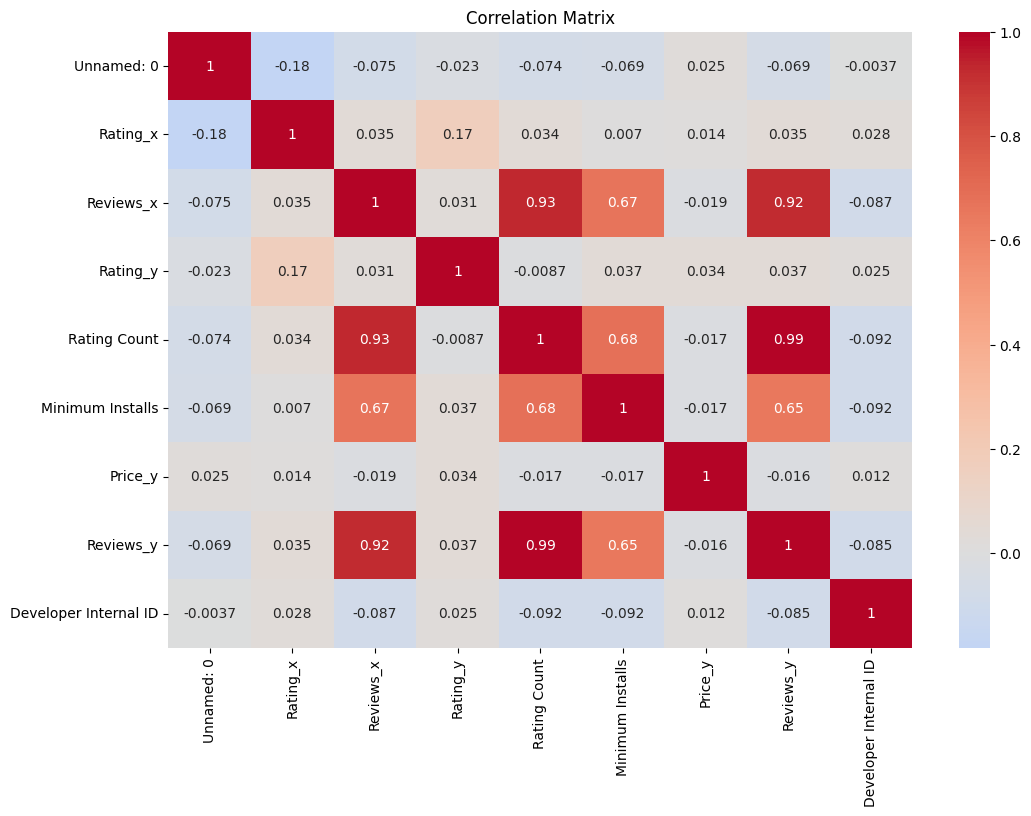

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

# انتخاب ویژگی‌های عددی برای محاسبه همبستگی
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns

# محاسبه ماتریس همبستگی
correlation_matrix = df[numeric_columns].corr()

# رسم نقشه حرارتی ماتریس همبستگی
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()


In [30]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering


df = pd.read_csv('E:\\datamining\\MergedDataset.csv', low_memory=False)
# تابع تبدیل داده‌های متنی به عددی
def convert_size(size):
    if isinstance(size, str):
        size = size.upper()
        if 'G' in size:
            return float(size.replace('G', '').replace(',', '')) * 1e9
        elif 'M' in size:
            return float(size.replace('M', '').replace(',', '')) * 1e6
        elif 'K' in size:
            return float(size.replace('K', '').replace(',', '')) * 1e3
        elif size == 'VARIES WITH DEVICE':
            return np.nan
    return np.nan

def convert_installs(installs):
    if isinstance(installs, str):
        installs = installs.replace(',', '').replace('+', '')
        try:
            return float(installs)
        except ValueError:
            return np.nan
    return np.nan

def convert_price(price):
    if isinstance(price, str):
        return pd.to_numeric(price.replace('$', '').replace(',', ''), errors='coerce')
    return np.nan

# پیش‌پردازش داده‌ها
df['Size_x'] = df['Size_x'].apply(convert_size)
df['Installs_x'] = df['Installs_x'].apply(convert_installs)
df['Reviews_x'] = pd.to_numeric(df['Reviews_x'], errors='coerce')
df['Price_x'] = df['Price_x'].apply(convert_price)

# حذف ردیف‌های خالی
df_clustering = df[['Size_x', 'Installs_x', 'Reviews_x', 'Price_x']].dropna()

# بررسی تعداد ردیف‌ها پس از حذف
print("Number of rows after dropping missing values:", len(df_clustering))

# استانداردسازی داده‌ها
scaler = StandardScaler()
df_clustering_scaled = scaler.fit_transform(df_clustering)



Number of rows after dropping missing values: 4963


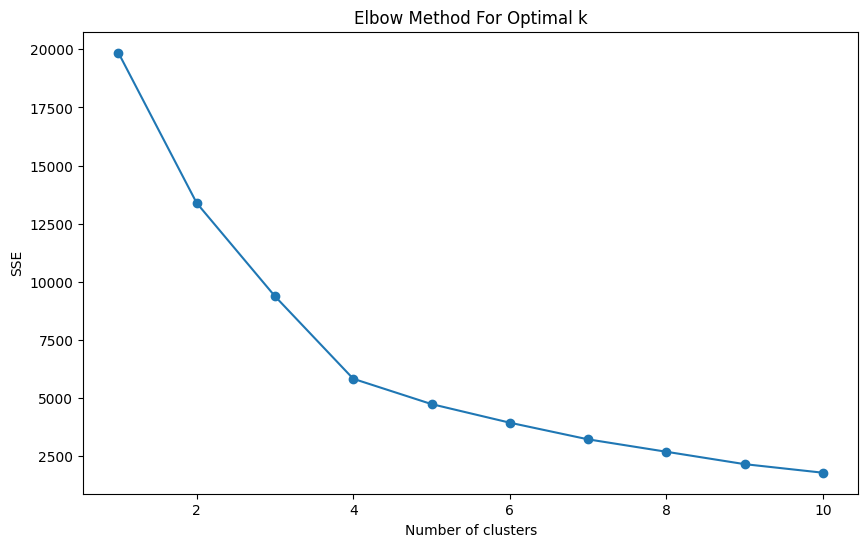

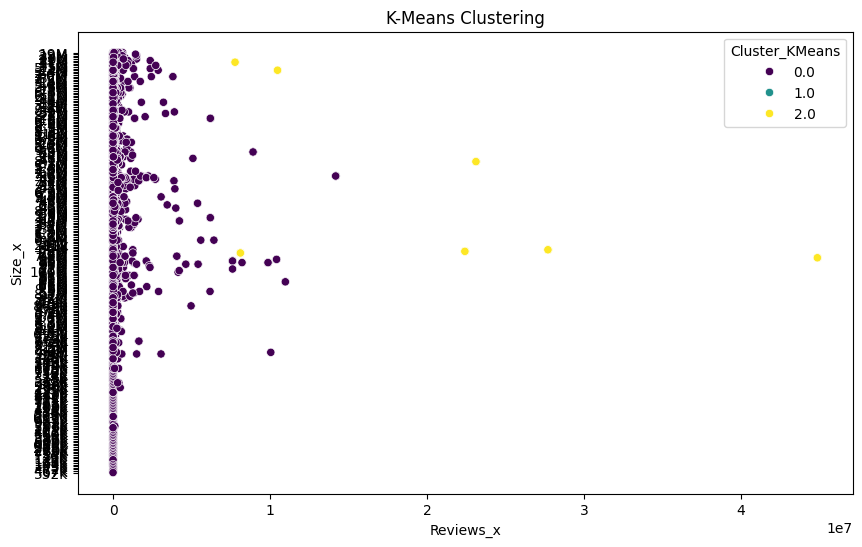

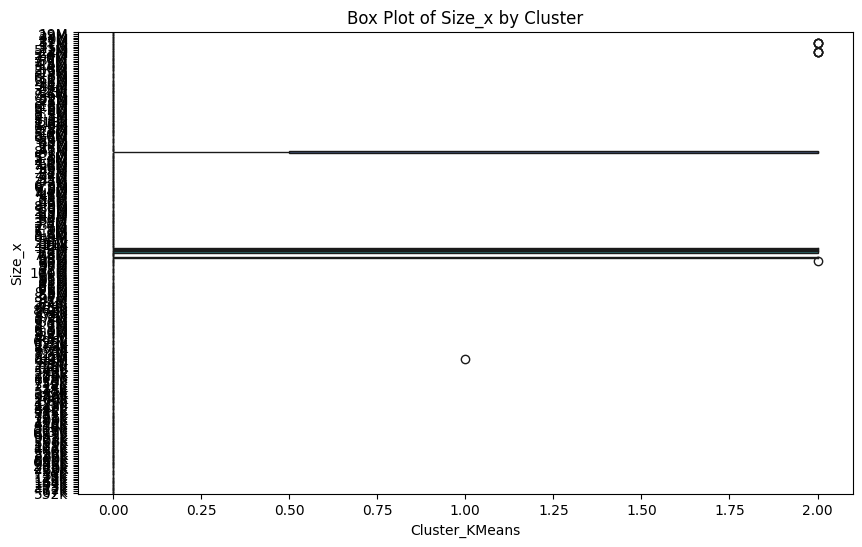

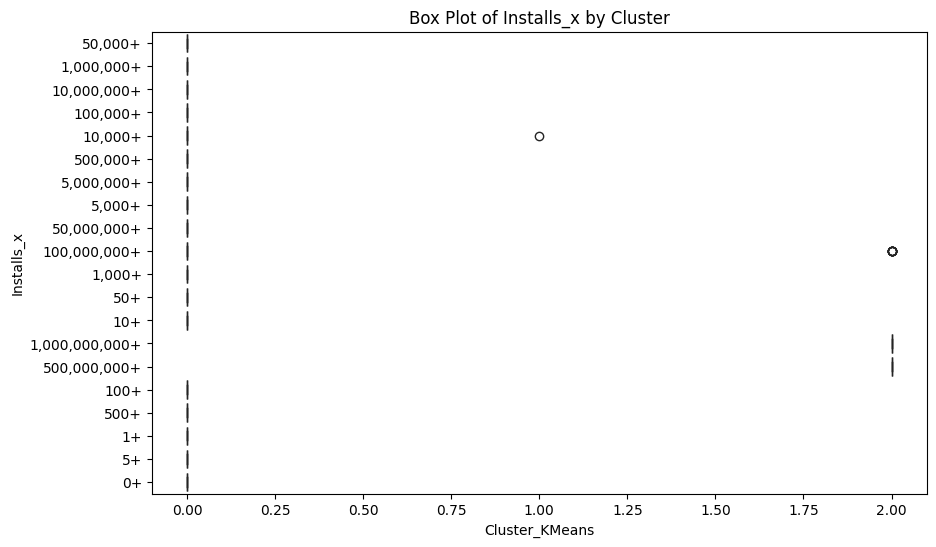

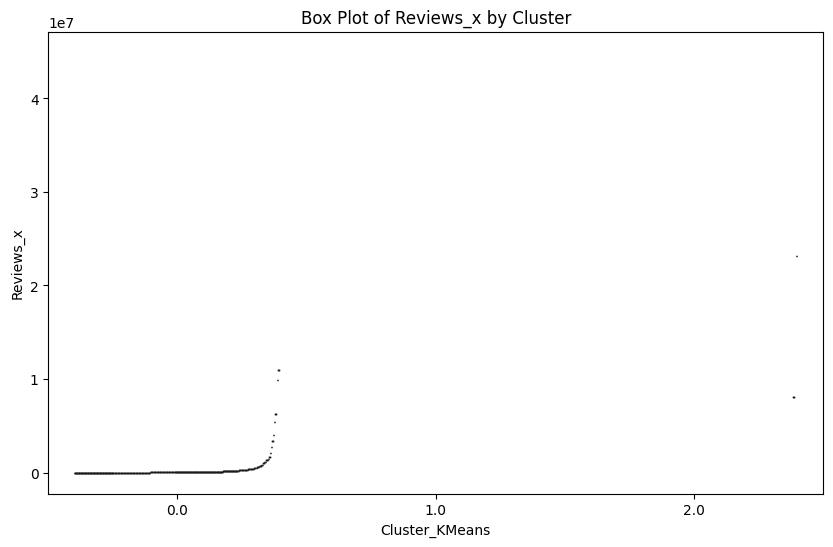

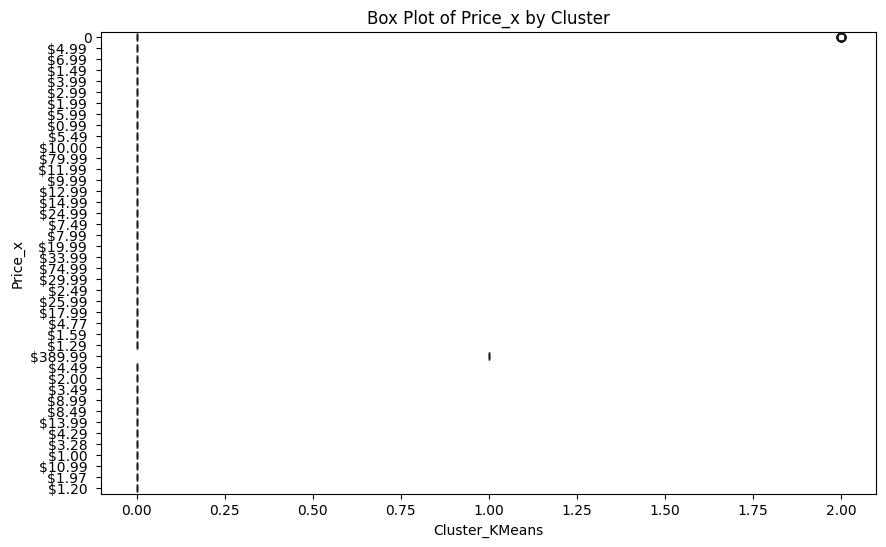

In [54]:

# Elbow method to determine optimal number of clusters
sse = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=0, n_init=10).fit(df_clustering_scaled)
    sse.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, sse, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('SSE')
plt.title('Elbow Method For Optimal k')
plt.show()

# K-Means clustering with optimal number of clusters (example: 3 clusters)
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=0, n_init=10).fit(df_clustering_scaled)
clusters_kmeans = kmeans.labels_

# Add clustering result to the original DataFrame
df.loc[df_clustering.index, 'Cluster_KMeans'] = clusters_kmeans

# Visualize clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df.loc[df_clustering.index], x='Reviews_x', y='Size_x', hue='Cluster_KMeans', palette='viridis')
plt.title('K-Means Clustering')
plt.show()


# Compare distributions using box plots
for column in ['Size_x', 'Installs_x', 'Reviews_x', 'Price_x']:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='Cluster_KMeans', y=column, hue=column, data=df.loc[df_clustering.index], palette='viridis', legend=False)
    plt.title(f'Box Plot of {column} by Cluster')
    plt.show()



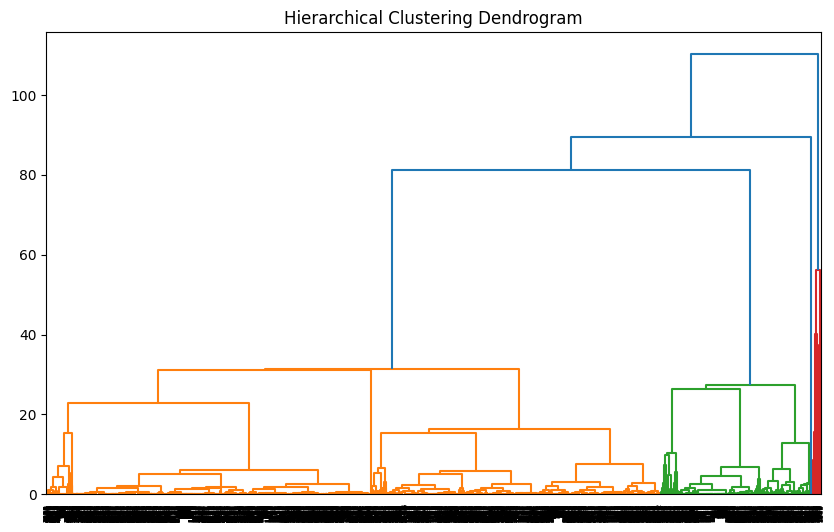

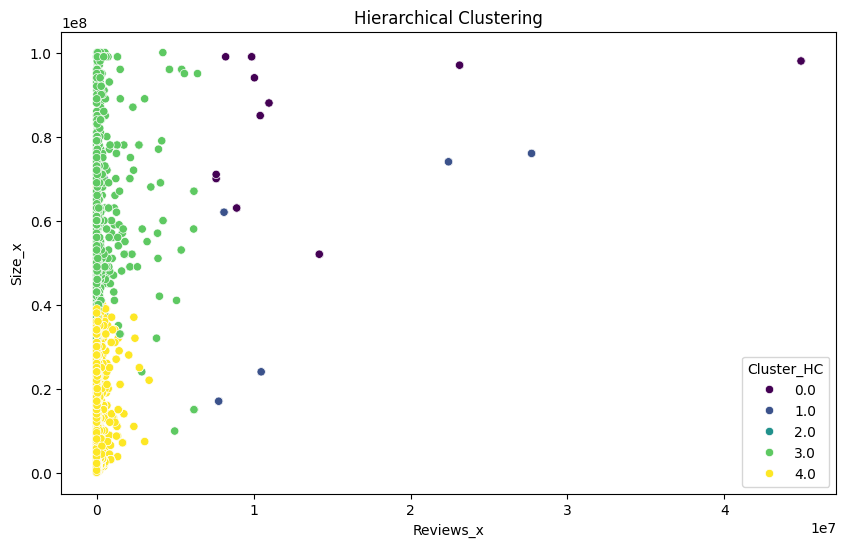

In [34]:
# اجرای خوشه‌بندی سلسله‌مراتبی
linked = linkage(df_clustering_scaled, method='ward')

# رسم دندروگرام
plt.figure(figsize=(10, 6))
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram')
plt.show()

# اجرای خوشه‌بندی سلسله‌مراتبی با تعداد خوشه‌های بهینه
optimal_k = 5  # تعداد خوشه‌های بهینه را تعیین کنید
hc = AgglomerativeClustering(n_clusters=optimal_k, metric='euclidean', linkage='ward')
clusters = hc.fit_predict(df_clustering_scaled)

# افزودن نتیجه خوشه‌بندی به DataFrame اصلی
df.loc[df_clustering.index, 'Cluster_HC'] = clusters

# تصویرسازی خوشه‌ها
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Reviews_x', y='Size_x', hue='Cluster_HC', palette='viridis')
plt.title('Hierarchical Clustering')
plt.show()



In [35]:
# بررسی میانگین ویژگی‌ها در هر خوشه (K-Means)
kmeans_summary = df.groupby('Cluster_KMeans')[selected_features].mean()
print("K-Means Clustering Summary:")
print(kmeans_summary)

# بررسی میانگین ویژگی‌ها در هر خوشه (سلسله‌مراتبی)
hc_summary = df.groupby('Cluster_HC')[selected_features].mean()
print("Hierarchical Clustering Summary:")
print(hc_summary)


K-Means Clustering Summary:
                   Reviews_x        Size_x    Installs_x     Price_x
Cluster_KMeans                                                      
0.0             2.194808e+05  2.174237e+07  7.120523e+06    0.422517
1.0             2.170000e+02  4.900000e+06  1.000000e+04  389.990000
2.0             1.993547e+07  6.555556e+07  4.944444e+08    0.000000
Hierarchical Clustering Summary:
               Reviews_x        Size_x    Installs_x     Price_x
Cluster_HC                                                      
0.0         1.605424e+07  7.888235e+07  1.000000e+08    0.000000
1.0         1.591385e+07  5.642857e+07  6.071429e+08    0.000000
2.0         2.170000e+02  4.900000e+06  1.000000e+04  389.990000
3.0         4.252252e+05  5.808314e+07  1.370828e+07    0.281374
4.0         1.012353e+05  1.253694e+07  4.900238e+06    0.459741


               Accuracy  Precision    Recall  F1-Score
Naive Bayes    0.413829   0.849753  0.413829  0.515049
Random Forest  0.901961   0.892182  0.901961  0.894567
Decision Tree  0.874097   0.882518  0.874097  0.877914


<Figure size 1000x600 with 0 Axes>

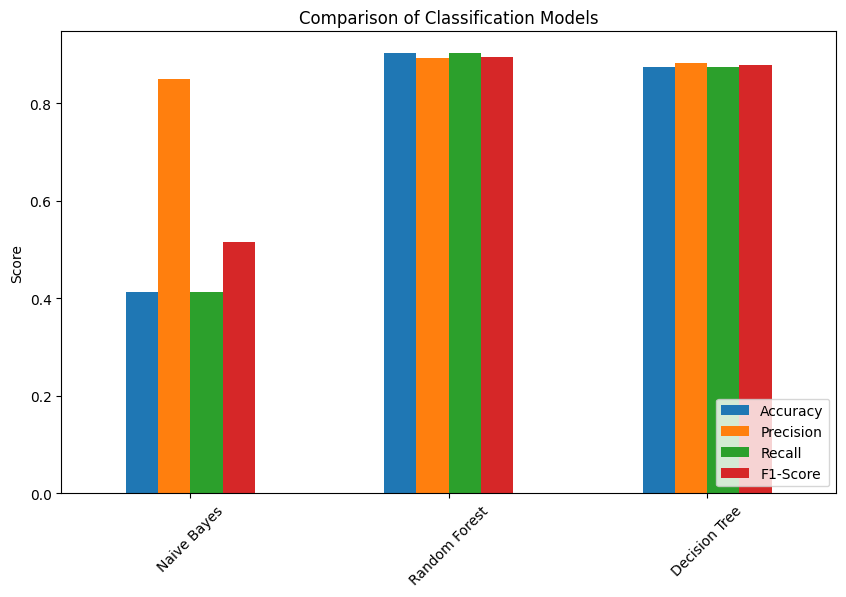

The best model is Random Forest with an F1-Score of 0.89


In [55]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Load data
df = pd.read_csv('E:\\datamining\\MergedDataset.csv', low_memory=False)

# Convert size from text to numeric
def convert_size(size):
    if isinstance(size, str):
        size = size.upper()
        if 'G' in size:
            return float(size.replace('G', '').replace(',', '')) * 1e9
        elif 'M' in size:
            return float(size.replace('M', '').replace(',', '')) * 1e6
        elif 'K' in size:
            return float(size.replace('K', '').replace(',', '')) * 1e3
        elif size == 'VARIES WITH DEVICE':
            return np.nan
    return np.nan

# Convert installs from text to numeric
def convert_installs(installs):
    if isinstance(installs, str):
        installs = installs.replace(',', '').replace('+', '')
        try:
            return float(installs)
        except ValueError:
            return np.nan
    return np.nan

# Convert price from text to numeric
def convert_price(price):
    if isinstance(price, str):
        return pd.to_numeric(price.replace('$', '').replace(',', ''), errors='coerce')
    return np.nan

# Data preprocessing
df['Size_x'] = df['Size_x'].apply(convert_size)
df['Installs_x'] = df['Installs_x'].apply(convert_installs)
df['Reviews_x'] = pd.to_numeric(df['Reviews_x'], errors='coerce')
df['Price_x'] = df['Price_x'].apply(convert_price)

# Select features for classification
df_classification = df[['Reviews_x', 'Size_x', 'Installs_x', 'Price_x', 'Content Rating_x', 'Rating_x']].dropna()

# Convert textual features to numerical
label_encoder = LabelEncoder()
df_classification['Content Rating_x'] = label_encoder.fit_transform(df_classification['Content Rating_x'])

# Standardize data
scaler = StandardScaler()
features = ['Reviews_x', 'Size_x', 'Installs_x', 'Price_x', 'Content Rating_x']
df_classification[features] = scaler.fit_transform(df_classification[features])

# Convert target values to discrete categories
def categorize_rating(rating):
    if rating < 3:
        return 'Low'
    elif rating < 4:
        return 'Medium'
    else:
        return 'High'

df_classification['Rating_Category'] = df_classification['Rating_x'].apply(categorize_rating)

# Encode target values
df_classification['Rating_Category'] = label_encoder.fit_transform(df_classification['Rating_Category'])

# Split data into training and testing sets
X = df_classification[features]
y = df_classification['Rating_Category']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Define models
models = {
    'Naive Bayes': GaussianNB(),
    'Random Forest': RandomForestClassifier(random_state=0),
    'Decision Tree': DecisionTreeClassifier(random_state=0)
}

# Train and evaluate models
results = {}
for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    results[model_name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    }

# Display results
results_df = pd.DataFrame(results).T
print(results_df)

# Visualize results
plt.figure(figsize=(10, 6))
results_df.plot(kind='bar', figsize=(10, 6))
plt.title('Comparison of Classification Models')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.show()

# Choose the best model
best_model = results_df['F1-Score'].idxmax()
best_model_score = results_df.loc[best_model, 'F1-Score']
print(f"The best model is {best_model} with an F1-Score of {best_model_score:.2f}")
